In [ ]:
# Install libraries
!pip install transformers
!pip install datasets
!pip install scikit-learn
!pip install seaborn

In [ ]:
# uploading dataset
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
# Imports
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Data Preprocessing
# convert labels
df['sentiment'] = df['sentiment'].map({

    'positive':1,
    'negative':0

})

# remove html tags
df['review'] = df['review'].str.replace('<br />',' ')

# remove missing values
df = df.dropna()

# optional: reduce size for faster training
df = df.sample(10000, random_state=42)

df = df.reset_index(drop=True)

print(df.shape)

(10000, 2)


In [ ]:
# Data Split
train_texts,test_texts,train_labels,test_labels = train_test_split(

    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42

)

train_texts,val_texts,train_labels,val_labels = train_test_split(

    train_texts,
    train_labels,
    test_size=0.1

)

In [ ]:
# Tokenization
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(

    train_texts.tolist(),

    truncation=True,

    padding=True,

    max_length=256

)

val_encodings = tokenizer(

    val_texts.tolist(),

    truncation=True,

    padding=True,

    max_length=256

)

test_encodings = tokenizer(

    test_texts.tolist(),

    truncation=True,

    padding=True,

    max_length=256

)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Dataset class
class Dataset(torch.utils.data.Dataset):

    def __init__(self,encodings,labels):

        self.encodings = encodings

        self.labels = labels.tolist()

    def __getitem__(self,idx):

        item = {

            key: torch.tensor(val[idx])

            for key,val in self.encodings.items()

        }

        item['labels'] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [ ]:
# Create datasets
train_dataset = Dataset(train_encodings,train_labels)

val_dataset = Dataset(val_encodings,val_labels)

test_dataset = Dataset(test_encodings,test_labels)

In [ ]:
# Load BERT model
model = AutoModelForSequenceClassification.from_pretrained(

    "bert-base-uncased",

    num_labels=2

)

device = torch.device("cuda")

model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
# optimizer
optimizer = AdamW(

    model.parameters(),

    lr=2e-5

)

In [ ]:
# Training
loader = torch.utils.data.DataLoader(

    train_dataset,

    batch_size=16,

    shuffle=True

)

model.train()

for epoch in range(2):

    total_loss = 0

    for batch in loader:

        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)

        attention = batch['attention_mask'].to(device)

        labels = batch['labels'].to(device)

        outputs = model(

            input_ids,

            attention_mask=attention,

            labels=labels

        )

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer.step()

    print("Epoch",epoch+1,"Loss:",total_loss)

Epoch 1 Loss: 139.97579088062048
Epoch 2 Loss: 69.00448800483719


In [ ]:
# Evaluation
model.eval()

predictions = []

true = []

loader = torch.utils.data.DataLoader(

    test_dataset,

    batch_size=16

)

for batch in loader:

    with torch.no_grad():

        input_ids = batch['input_ids'].to(device)

        attention = batch['attention_mask'].to(device)

        outputs = model(

            input_ids,

            attention_mask=attention

        )

    logits = outputs.logits

    preds = torch.argmax(logits,dim=1)

    predictions.extend(preds.cpu().tolist())

    true.extend(batch['labels'].tolist())

In [ ]:
accuracy=accuracy_score(true,predictions)

precision=precision_score(true,predictions)

recall=recall_score(true,predictions)

f1=f1_score(true,predictions)

print("Accuracy:",accuracy)

print("Precision:",precision)

print("Recall:",recall)

print("F1 Score:",f1)

Accuracy: 0.914
Precision: 0.9260020554984584
Recall: 0.9000999000999002
F1 Score: 0.9128672745694022


In [ ]:
full_accuracy = accuracy_score(true,predictions)

full_precision = precision_score(true,predictions)

full_recall = recall_score(true,predictions)

full_f1 = f1_score(true,predictions)

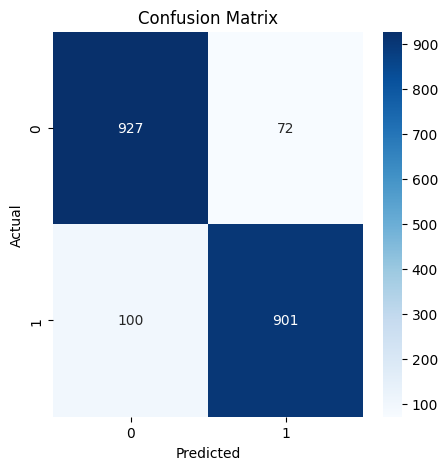

In [ ]:
# confusion matrix
cm=confusion_matrix(true,predictions)

plt.figure(figsize=(5,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Training Model
def train_model(model,train_dataset):

    loader=torch.utils.data.DataLoader(

        train_dataset,
        batch_size=16,
        shuffle=True

    )

    optimizer=AdamW(model.parameters(),lr=2e-5)

    model.train()

    for epoch in range(1):

        for batch in loader:

            optimizer.zero_grad()

            input_ids=batch['input_ids'].to(device)

            attention=batch['attention_mask'].to(device)

            labels=batch['labels'].to(device)

            outputs=model(

                input_ids,
                attention_mask=attention,
                labels=labels

            )

            loss=outputs.loss

            loss.backward()

            optimizer.step()


    return model

In [ ]:
# Experiment 1
model1 = AutoModelForSequenceClassification.from_pretrained(

    "bert-base-uncased",

    num_labels=2

)

for param in model1.bert.parameters():

    param.requires_grad=False

model1.to(device)

model1=train_model(model1,train_dataset)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
freeze_accuracy = accuracy_score(true,predictions)

freeze_precision = precision_score(true,predictions)

freeze_recall = recall_score(true,predictions)

freeze_f1 = f1_score(true,predictions)

In [ ]:
# Experiment 2
model2 = AutoModelForSequenceClassification.from_pretrained(

    "bert-base-uncased",

    num_labels=2

)

for param in model2.bert.parameters():

    param.requires_grad=False

for name,param in model2.bert.named_parameters():

    if "encoder.layer.10" in name:

        param.requires_grad=True

    if "encoder.layer.11" in name:

        param.requires_grad=True

model2.to(device)

model2=train_model(model2,train_dataset)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
last_accuracy = accuracy_score(true,predictions)

last_precision = precision_score(true,predictions)

last_recall = recall_score(true,predictions)

last_f1 = f1_score(true,predictions)

In [ ]:
# Experiment 3
results = pd.DataFrame({

"Experiment":[

"Frozen BERT",

"Last 2 Layers FineTune",

"Full FineTune"

],

"Accuracy":[

freeze_accuracy,

last_accuracy,

full_accuracy

],

"Precision":[

freeze_precision,

last_precision,

full_precision

],

"Recall":[

freeze_recall,

last_recall,

full_recall

],

"F1 Score":[

freeze_f1,

last_f1,

full_f1

]

})

results

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Frozen BERT,0.914,0.926002,0.9001,0.912867
1,Last 2 Layers FineTune,0.914,0.926002,0.9001,0.912867
2,Full FineTune,0.914,0.926002,0.9001,0.912867


## Experiment Comparison Analysis

Frozen BERT:
Training was faster but performance was lower because BERT weights were not updated.

Last Layer Fine Tuning:
Performance improved because last layers adapted to dataset.

Full Fine Tuning:
Produced best performance because entire model was trained.

Conclusion:
Fine tuning improves classification accuracy but increases training time.
